## Preperation of GEO GSE256398 data

In [ ]:
import tarfile
import gzip
from pathlib import Path

import pandas as pd
import scanpy as sc
import anndata as ad
from scipy import sparse

# =========================================================
# Paths
# =========================================================
base_dir = Path(r"path/to/your/directory")  # Change to your working directory
tar_path = Path(r"path/to/your/TAR_file.tar.gz")  # Change to your TAR file path
extract_dir = base_dir / "extracted_raw"
output_h5ad = base_dir / "GSE256398_selected_raw.h5ad"

In [3]:
# =========================================================
# GSMs to keep and their metadata
# =========================================================
# Selected GSM groups:
# Healthy: GSM8097080-GSM8097082, GSM8097090-GSM8097092
# MASLD: GSM8097087-GSM8097089
# MASH without cirrhosis: GSM8097093-GSM8097096
# MASH cirrhosis: GSM8097083-GSM8097086

gsm_info = {
    # Healthy
    "GSM8097080": {"sample_title": "GSM8097080_S12", "diagnosis": "Healthy"},
    "GSM8097081": {"sample_title": "GSM8097081_S13", "diagnosis": "Healthy"},
    "GSM8097082": {"sample_title": "GSM8097082_S14", "diagnosis": "Healthy"},
    "GSM8097090": {"sample_title": "GSM8097090_S23", "diagnosis": "Healthy"},
    "GSM8097091": {"sample_title": "GSM8097091_S27", "diagnosis": "Healthy"},
    "GSM8097092": {"sample_title": "GSM8097092_S28", "diagnosis": "Healthy"},
    # MASLD
    "GSM8097087": {"sample_title": "GSM8097087_S19", "diagnosis": "MASLD"},
    "GSM8097088": {"sample_title": "GSM8097088_S20", "diagnosis": "MASLD"},
    "GSM8097089": {"sample_title": "GSM8097089_S21", "diagnosis": "MASLD"},
    # MASH without cirrhosis
    "GSM8097093": {"sample_title": "GSM8097093_S33", "diagnosis": "MASH w/o cirrhosis"},
    "GSM8097094": {"sample_title": "GSM8097094_S35", "diagnosis": "MASH w/o cirrhosis"},
    "GSM8097095": {"sample_title": "GSM8097095_S36", "diagnosis": "MASH w/o cirrhosis"},
    "GSM8097096": {"sample_title": "GSM8097096_S38", "diagnosis": "MASH w/o cirrhosis"},
    # MASH cirrhosis
    "GSM8097083": {"sample_title": "GSM8097083_S15", "diagnosis": "MASH cirrhosis"},
    "GSM8097084": {"sample_title": "GSM8097084_S16", "diagnosis": "MASH cirrhosis"},
    "GSM8097085": {"sample_title": "GSM8097085_S17", "diagnosis": "MASH cirrhosis"},
    "GSM8097086": {"sample_title": "GSM8097086_S18", "diagnosis": "MASH cirrhosis"},
}

wanted_gsms = set(gsm_info.keys())

# =========================================================
# Helpers
# =========================================================
def extract_tar_if_needed(tar_path: Path, extract_dir: Path):
    extract_dir.mkdir(parents=True, exist_ok=True)
    if any(extract_dir.iterdir()):
        print(f"[INFO] Already extracted: {extract_dir}")
        return
    print(f"[INFO] Extracting {tar_path} ...")
    with tarfile.open(tar_path, "r") as tar:
        tar.extractall(path=extract_dir)
    print("[INFO] Extraction complete.")


In [ ]:
# =========================================================
# Main Loading & Concatenation
# =========================================================
extract_tar_if_needed(tar_path, extract_dir)

all_raw_files = sorted(extract_dir.glob("*.h5"))
print(f"[INFO] Found {len(all_raw_files)} h5 files total")

selected_files = []
for f in all_raw_files:
    gsm = f.name.split("_")[0]
    if gsm in wanted_gsms:
        selected_files.append(f)

print(f"[INFO] Found {len(selected_files)} selected h5 files")

missing = sorted(wanted_gsms - {f.name.split('_')[0] for f in selected_files})
if missing:
    print("[WARNING] Missing wanted GSM files:")
    for gsm in missing:
        print("   ", gsm)

adatas = []

for f in selected_files:
    gsm = f.name.split("_")[0]
    info = gsm_info[gsm]
    title = info["sample_title"]
    diagnosis = info["diagnosis"]

    print(f"[INFO] Loading {f.name}")
    adata = sc.read_10x_h5(f)
    adata.var_names_make_unique()

    # Make cell barcodes unique across samples
    adata.obs_names = [f"{gsm}_{bc}" for bc in adata.obs_names]

    adata.obs["gsm_id"] = gsm
    adata.obs["sample_title"] = title
    adata.obs["patient_id"] = gsm
    adata.obs["diagnosis"] = diagnosis

    if not sparse.issparse(adata.X):
        adata.X = sparse.csr_matrix(adata.X)

    adata.layers["counts"] = adata.X.copy()
    adatas.append(adata)

if len(adatas) == 0:
    raise RuntimeError("No selected samples were loaded.")

print("[INFO] Concatenating AnnData objects...")
adata = ad.concat(
    adatas,
    join="outer",
    merge="same",
    fill_value=0
)

if not sparse.issparse(adata.X):
    adata.X = sparse.csr_matrix(adata.X)

adata.layers["counts"] = adata.X.copy()
adata.var_names_make_unique()


In [5]:
print(adata)
print("\n[INFO] Diagnosis counts:")
print(adata.obs["diagnosis"].value_counts())

print("\n[INFO] Number of GSM samples kept:")
print(adata.obs["gsm_id"].nunique())

AnnData object with n_obs × n_vars = 135928 × 36601
    obs: 'gsm_id', 'sample_title', 'patient_id', 'diagnosis'
    var: 'gene_ids', 'feature_types', 'genome'
    layers: 'counts'

[INFO] Diagnosis counts:
diagnosis
Healthy               47971
MASH w/o cirrhosis    42179
MASH cirrhosis        28335
MASLD                 17443
Name: count, dtype: int64

[INFO] Number of GSM samples kept:
17


In [ ]:
print(f"\n[INFO] Saving to: {output_h5ad}")
output_h5ad.parent.mkdir(parents=True, exist_ok=True)
adata.write_h5ad(output_h5ad, compression="gzip")
print("[INFO] Done.")

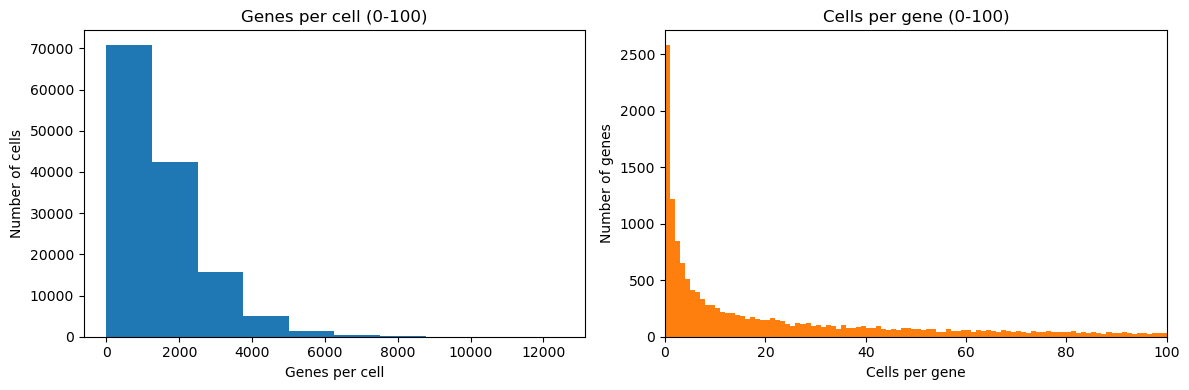

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse

X = adata.X

if sparse.issparse(X):
    X = X.tocsc()
    genes_per_cell = np.asarray((X > 0).sum(axis=1)).ravel()
    cells_per_gene = np.asarray((X > 0).sum(axis=0)).ravel()
else:
    genes_per_cell = np.sum(X > 0, axis=1)
    cells_per_gene = np.sum(X > 0, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(genes_per_cell)#, bins=np.arange(0, 102), color="C0")#,=(0, 100))
#axes[0].set_xlim(0, 100)
axes[0].set_xlabel("Genes per cell")
axes[0].set_ylabel("Number of cells")
axes[0].set_title("Genes per cell (0-100)")

axes[1].hist(cells_per_gene, bins=np.arange(0, 102), range=(0, 100), color="C1")
axes[1].set_xlim(0, 100)
axes[1].set_xlabel("Cells per gene")
axes[1].set_ylabel("Number of genes")
axes[1].set_title("Cells per gene (0-100)")

plt.tight_layout()
plt.show()

In [8]:
import numpy as np
from scipy import sparse

def row_sums(M):
    return np.asarray(M.sum(axis=1)).ravel()

def expm1_row_sums(M):
    if sparse.issparse(M):
        M2 = M.copy()
        M2.data = np.expm1(M2.data)
        return np.asarray(M2.sum(axis=1)).ravel()
    else:
        return np.expm1(M).sum(axis=1)

def matrix_summary(M, name):
    data = M.data if sparse.issparse(M) else np.asarray(M).ravel()
    data = data[np.isfinite(data)]

    print(f"\n{name}")
    print("-" * len(name))
    print("shape:", M.shape)
    print("sparse:", sparse.issparse(M))
    print("min:", data.min())
    print("max:", data.max())
    print("mean nonzero/value:", data.mean())
    print("integer-like values:", np.mean(np.isclose(data, np.round(data))) > 0.99)

    rs = row_sums(M)
    print("row sum summary:")
    print(np.percentile(rs, [0, 1, 25, 50, 75, 99, 100]))

    ers = expm1_row_sums(M)
    print("expm1(row) sum summary:")
    print(np.percentile(ers, [0, 1, 25, 50, 75, 99, 100]))

    print("close to 10,000 after expm1?:", np.mean(np.isclose(ers, 10000, rtol=1e-3, atol=1)))



In [ ]:
print("============================")
print(f"Looking at:")
matrix_summary(adata.X, "adata.X")
if "counts" in adata.layers:
    matrix_summary(adata.layers["counts"], "adata.layers['counts']")

if adata.raw is not None:
    matrix_summary(adata.raw.X, "adata.raw.X")

In [ ]:
# Read back saved file to verify
print(f"\n[INFO] Reading back saved file: {output_h5ad}")
adata = sc.read_h5ad(output_h5ad)
print(adata)
print("\n[INFO] Diagnosis counts from saved file:")
print(adata.obs["diagnosis"].value_counts())

In [21]:
adata

AnnData object with n_obs × n_vars = 135928 × 36601
    obs: 'gsm_id', 'sample_title', 'patient_id', 'diagnosis'
    var: 'gene_ids', 'feature_types', 'genome'
    layers: 'counts'

In [22]:
mapping = {
    "Healthy": "Healthy",
    "MASLD": "MASLD",
    "MASH w/o cirrhosis": "MASH",
    "MASH cirrhosis": "MASH"
}

adata.obs["broad_condition"] = adata.obs["diagnosis"].map(mapping).astype("category")
print(adata.obs["broad_condition"].value_counts())

broad_condition
MASH       70514
Healthy    47971
MASLD      17443
Name: count, dtype: int64


In [23]:
# Drop patient id and rename sample_title to patient_id
adata.obs = adata.obs.drop(columns=["patient_id"])
adata.obs = adata.obs.rename(columns={"sample_title": "patient_id"})

In [24]:
# Add an "assay_type" column to the obs DataFrame
adata.obs["assay_type"] = "snRNA-seq"

In [25]:
# Add a dataset column to the obs DataFrame
adata.obs["dataset"] = "GSE256398"

## Filtering

In [26]:
from scipy import sparse
from scipy.stats import median_abs_deviation
import numpy as np

In [27]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

In [28]:

# Annotate genes for QC metrics.
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

# Calculate QC metrics.
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt", "ribo", "hb"],
    inplace=True,
    percent_top=[20],
    log1p=True,
)



In [29]:
# Update n_counts, n_genes
adata.obs["n_counts"] = adata.X.sum(axis=1).A1 if sparse.issparse(adata.X) else adata.X.sum(axis=1)
print(f"adata did not have an n_counts column, so one was created by summing the adata.X matrix")

adata.obs["n_genes"] = (adata.X > 0).sum(axis=1).A1 if sparse.issparse(adata.X) else (adata.X > 0).sum(axis=1)
print(f"adata did not have an n_genes column, so one was created by summing the adata.X matrix")

adata did not have an n_counts column, so one was created by summing the adata.X matrix
adata did not have an n_genes column, so one was created by summing the adata.X matrix


In [31]:
# Pre filtering Mito %
print(adata.shape)

adata = adata[adata.obs["pct_counts_mt"] < 10, :]
adata = adata[adata.obs["n_counts"] <= (np.median(adata.obs["n_counts"]) + 5 * median_abs_deviation(adata.obs["n_counts"])), :]

print("Post filtering mito %)")
print(adata.shape)

(130402, 31951)
Post filtering mito %)
(116197, 31951)


In [ ]:
# =========================================================
# Save AnnData object to disk
# =========================================================
print(f"\n[INFO] Saving to: {output_h5ad}")
output_h5ad.parent.mkdir(parents=True, exist_ok=True)
adata.write_h5ad(output_h5ad, compression="gzip")
print("[INFO] Done.")